C:\Users\Redie\AppData\Local\Temp\ipykernel_20560\2443122636.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv('../data/BrentOilPrices.csv', parse_dates=['Date'], index_col='Date')


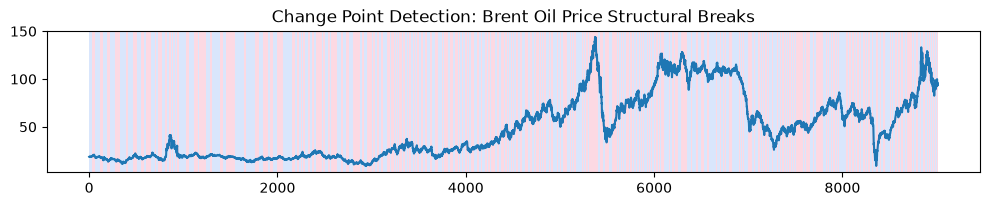

Detected Change Point Dates:
DatetimeIndex(['1987-07-02', '1987-08-13', '1987-11-05', '1987-12-10',
               '1988-02-17', '1988-04-08', '1988-06-10', '1988-09-02',
               '1988-11-25', '1989-01-03',
               ...
               '2022-07-07', '2022-07-14', '2022-07-21', '2022-08-04',
               '2022-08-18', '2022-09-02', '2022-09-16', '2022-10-03',
               '2022-10-17', '2022-10-31'],
              dtype='datetime64[us]', name='Date', length=617, freq=None)


In [2]:
import ruptures as rpt
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('../data/BrentOilPrices.csv', parse_dates=['Date'], index_col='Date')
df = df.sort_index()
# Convert your price column to a numpy array for processing
price_data = df['Price'].values

# Use PELT (Pruned Exact Linear Time) algorithm, which is efficient for this size of data
# model='l2' looks for changes in the mean
algo = rpt.Pelt(model="l2").fit(price_data)

# Detect change points
# pen=10 is a penalty value; increase it to find fewer change points
result = algo.predict(pen=10)

# Display the results
rpt.display(price_data, result)
plt.title('Change Point Detection: Brent Oil Price Structural Breaks')
plt.show()

# Print the dates of the detected changes
change_point_dates = df.index[result[:-1]]
print("Detected Change Point Dates:")
print(change_point_dates)